# Seed-set quality: exploration, regression, and classification

This notebook analyzes a dataset produced by `cross_pair_seed_set_quality.data_collection` using a deliberately short feature panel. It fits regressors for H0 and final unseeded accuracy, then classifies whether final unseeded accuracy reaches `SUCCESS_THRESHOLD`.

All validation splits keep complete graph pairs together. Predictors use Graph A seed-set summaries and correspondence-free graph-pair context; H0 and other SGM outputs are outcomes rather than predictors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    log_loss,
    make_scorer,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
SUCCESS_THRESHOLD = 0.90
TEST_FRACTION = 0.25
plt.rcParams.update({'figure.figsize': (8, 5), 'axes.grid': True})

## Load one collected dataset

Set `GRAPH_MODEL` to select a collected dataset. `paper` is the historical Pareto-weight Chung–Lu graph; `paper_pa` is the new preferential-attachment-plus-ER PAPER graph.

In [2]:
EXPERIMENT_DIR = Path.cwd().resolve()
if EXPERIMENT_DIR.name != "cross_pair_seed_set_quality":
    EXPERIMENT_DIR = EXPERIMENT_DIR / "cross_pair_seed_set_quality"
GRAPH_MODEL = 'paper_pa'  # Or 'paper_pa', 'sparse_er', 'sparse_sbm', 'ier'
DATA_PATH = EXPERIMENT_DIR / f'data/seed_quality_{GRAPH_MODEL}.csv'

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Could not find {DATA_PATH.resolve()}. Generate the dataset or change DATA_PATH.'
    )

df = pd.read_csv(DATA_PATH)

SUPPORTED_FEATURE_SCHEMA_VERSIONS = {3}
if 'feature_schema_version' not in df.columns:
    raise ValueError(
        'This dataset uses the old feature schema. Refresh it with '
        'python -m cross_pair_seed_set_quality.data_collection --features-only before running the notebook.'
    )
schema_versions = set(df['feature_schema_version'].dropna().astype(int))
if len(schema_versions) != 1 or not schema_versions <= SUPPORTED_FEATURE_SCHEMA_VERSIONS:
    raise ValueError(
        f'Expected feature schema 3, but found {sorted(schema_versions)}. '
        'Refresh the dataset with python -m cross_pair_seed_set_quality.data_collection --features-only.'
    )

print(f'File: {DATA_PATH}')
print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
print(f"Graph pairs: {df['graph_pair_id'].nunique()}")
df.head()

File: /Users/langsong/Desktop/Seeded-Graph-Matching/cross_pair_seed_set_quality/data/seed_quality_paper_pa.csv
Rows: 1,000
Columns: 51
Graph pairs: 20


,feature_schema_version,graph_model,graph_pair_key,graph_pair_id,candidate_id,graph_pair_seed,sgm_seed,seed_vertices_graph1,seed_vertices_graph2,n_vertices,...,seed_nonseed_neighborhood_jaccard_mean,seed_pair_shortest_path_mean,seed_community_normalized_entropy,h0_accuracy,final_unseeded_accuracy,final_all_accuracy,sgm_runtime_seconds,sgm_n_iter,sgm_converged,sgm_objective_score
0,3,paper_pa,paper_pa_0,0,0,4206279609,3627193915,"[61, 69, 81, 100, 143, 153, 157, 187, 189, 221...","[498, 500, 519, 572, 459, 306, 525, 457, 595, ...",600,...,0.006953,3.705263,0.840613,0.082759,0.981034,0.981667,0.877581,30,False,2340.0
1,3,paper_pa,paper_pa_0,0,1,4206279609,2165122571,"[1, 24, 35, 82, 94, 105, 115, 150, 239, 260, 2...","[100, 208, 544, 268, 196, 156, 575, 587, 548, ...",600,...,0.005958,3.721053,0.773487,0.067241,0.706897,0.716667,0.974822,30,False,1886.0
2,3,paper_pa,paper_pa_0,0,2,4206279609,2546160292,"[4, 55, 164, 194, 220, 251, 266, 272, 288, 445...","[316, 331, 79, 60, 286, 443, 242, 89, 130, 511...",600,...,0.007325,4.010526,0.840613,0.072414,0.984483,0.985000,0.868852,30,False,2340.0
3,3,paper_pa,paper_pa_0,0,3,4206279609,2971063915,"[14, 71, 145, 146, 167, 171, 182, 248, 271, 29...","[579, 419, 486, 125, 324, 179, 339, 349, 206, ...",600,...,0.005259,4.078947,0.805356,0.062069,0.986207,0.986667,0.876308,30,False,2340.0
4,3,paper_pa,paper_pa_0,0,4,4206279609,372713037,"[13, 19, 42, 44, 49, 79, 81, 129, 205, 243, 26...","[330, 337, 485, 31, 516, 332, 519, 214, 311, 1...",600,...,0.006920,4.057895,0.770100,0.055172,0.981034,0.981667,0.891645,30,False,2338.0


## Basic checks and outcome distributions

In [3]:
rows_per_pair = df.groupby('graph_pair_id').size()
performance_columns = [
    'h0_accuracy',
    'final_unseeded_accuracy',
    'final_all_accuracy',
    'sgm_runtime_seconds',
    'sgm_n_iter',
]

print('Rows per graph pair:')
print(rows_per_pair.describe().to_string())
print(f"\nDuplicate graph-pair/candidate IDs: {df.duplicated(['graph_pair_id', 'candidate_id']).sum()}")
df[performance_columns].describe().T

Rows per graph pair:
count    20.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0

Duplicate graph-pair/candidate IDs: 0


,count,mean,std,min,25%,50%,75%,max
h0_accuracy,1000.0,0.066053,0.009447,0.034483,0.060345,0.065517,0.072414,0.096552
final_unseeded_accuracy,1000.0,0.760909,0.286688,0.125862,0.463362,0.958621,0.972414,0.996552
final_all_accuracy,1000.0,0.768878,0.277132,0.155000,0.481250,0.960000,0.973333,0.996667
sgm_runtime_seconds,1000.0,0.935787,0.133735,0.459817,0.907527,0.930808,0.956231,4.401152
sgm_n_iter,1000.0,29.600000,1.620069,15.000000,30.000000,30.000000,30.000000,30.000000


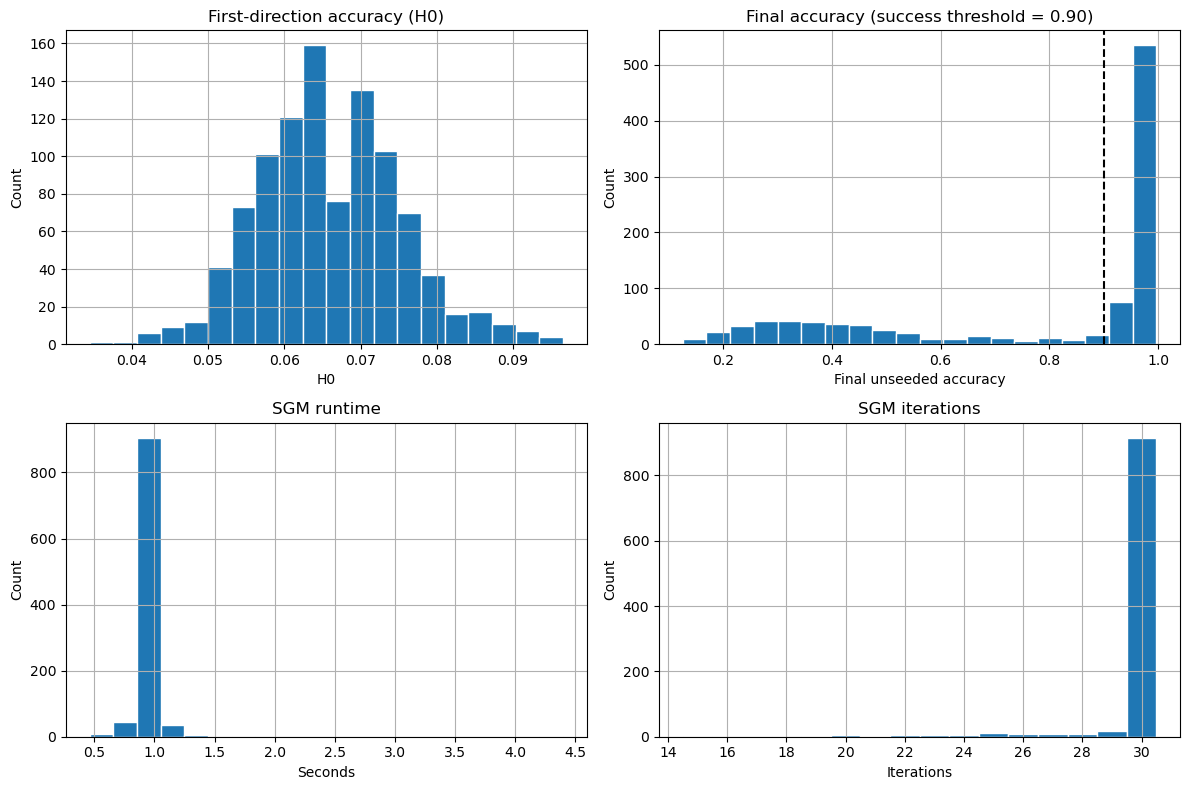

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df['h0_accuracy'], bins=20, edgecolor='white')
axes[0, 0].set(title='First-direction accuracy (H0)', xlabel='H0', ylabel='Count')

axes[0, 1].hist(df['final_unseeded_accuracy'], bins=20, edgecolor='white')
axes[0, 1].axvline(SUCCESS_THRESHOLD, color='black', linestyle='--')
axes[0, 1].set(
    title=f'Final accuracy (success threshold = {SUCCESS_THRESHOLD:.2f})',
    xlabel='Final unseeded accuracy',
    ylabel='Count',
)

axes[1, 0].hist(df['sgm_runtime_seconds'], bins=20, edgecolor='white')
axes[1, 0].set(title='SGM runtime', xlabel='Seconds', ylabel='Count')

iteration_bins = np.arange(df['sgm_n_iter'].min(), df['sgm_n_iter'].max() + 2) - 0.5
axes[1, 1].hist(df['sgm_n_iter'], bins=iteration_bins, edgecolor='white')
axes[1, 1].set(title='SGM iterations', xlabel='Iterations', ylabel='Count')

fig.tight_layout()
plt.show()

## Relationship between H0 and final accuracy

H0 needs the simulated ground-truth correspondence, so it is analyzed as an outcome and is never included as a predictor.

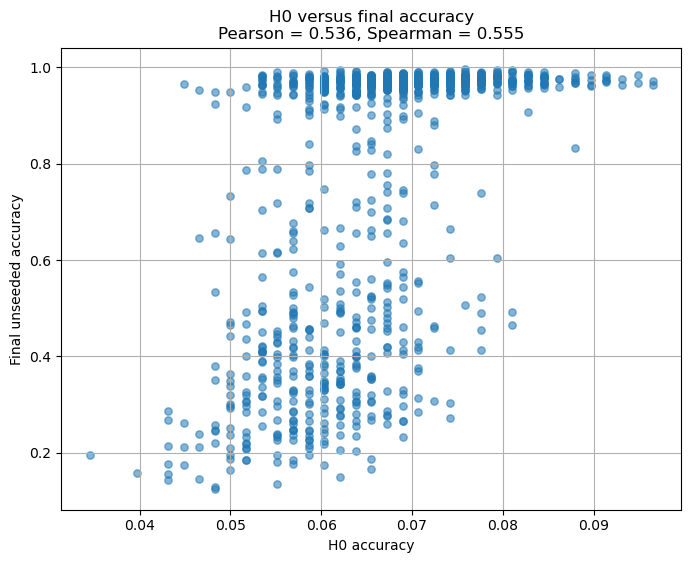

In [5]:
pearson_h0_final = df['h0_accuracy'].corr(df['final_unseeded_accuracy'])
spearman_h0_final = df['h0_accuracy'].corr(
    df['final_unseeded_accuracy'], method='spearman'
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['h0_accuracy'], df['final_unseeded_accuracy'], alpha=0.55, s=28)
ax.set(
    title=(
        f'H0 versus final accuracy\n'
        f'Pearson = {pearson_h0_final:.3f}, Spearman = {spearman_h0_final:.3f}'
    ),
    xlabel='H0 accuracy',
    ylabel='Final unseeded accuracy',
)
plt.show()

## Initial essential predictors

The initial panel contains 15 Graph A seed-set features. It covers centrality, direct and multi-hop coverage, distance to the seed set, redundancy, dispersion, and community spread. Two retained CSV features are deliberately omitted initially: three-witness coverage is often nearly zero in sparse graphs, and signature collision fraction is strongly redundant with signature entropy.

Four compact graph-pair summaries are included to describe graph difficulty across pairs. Set `INCLUDE_GRAPH_CONTEXT = False` to fit a seed-set-only model.

In [6]:
ESSENTIAL_SEED_FEATURES = [
    # Centrality
    'seed_degree_mean',
    'seed_pagerank_mean',
    'seed_betweenness_mean',
    # One-hop coverage and witness redundancy
    'nonseed_covered_fraction',
    'nonseed_covered_by_two_fraction',
    'nonseed_seed_neighbor_q10',
    # Shortest-distance and multi-hop coverage
    'nonseed_nearest_seed_distance_mean',
    'nonseed_nearest_seed_distance_max',
    'nonseed_nearest_seed_distance_disconnected_fraction',
    'nonseed_within_two_hops_of_three_seeds_fraction',
    'nonseed_three_hop_seed_count_mean',
    # Redundancy and seed dispersion
    'nonseed_seed_signature_normalized_entropy',
    'seed_nonseed_neighborhood_jaccard_mean',
    'seed_pair_shortest_path_mean',
    'seed_community_normalized_entropy',
]

GRAPH_CONTEXT_FEATURES = [
    'pair_degree_mean_average',
    'pair_degree_cv_average',
    'pair_largest_component_fraction_min',
    'pair_sorted_degree_mean_absolute_difference',
]

INCLUDE_GRAPH_CONTEXT = True
requested_features = ESSENTIAL_SEED_FEATURES + (
    GRAPH_CONTEXT_FEATURES if INCLUDE_GRAPH_CONTEXT else []
)
missing_features = sorted(set(requested_features) - set(df.columns))
if missing_features:
    raise ValueError(
        f'Missing expected features: {missing_features}. '
        'Refresh the CSV with python -m cross_pair_seed_set_quality.data_collection --features-only.'
    )

constant_features = [
    feature for feature in requested_features if df[feature].nunique(dropna=False) <= 1
]
feature_columns = [
    feature for feature in requested_features if feature not in constant_features
]

X = df[feature_columns].replace([np.inf, -np.inf], np.nan)
groups = df['graph_pair_key'] if 'graph_pair_key' in df else df['graph_pair_id']

CONTINUOUS_TARGETS = ['h0_accuracy', 'final_unseeded_accuracy']
CLASS_TARGET = 'seed_set_success'
df[CLASS_TARGET] = (df['final_unseeded_accuracy'] >= SUCCESS_THRESHOLD).astype(int)
y_class = df[CLASS_TARGET]

if groups.nunique() < 2:
    raise ValueError('Grouped evaluation requires at least two graph pairs.')
if y_class.nunique() != 2:
    raise ValueError(
        'The success threshold does not produce both classes. '
        'Choose a threshold inside the observed final-accuracy range.'
    )

print(f'Requested essential predictors: {len(requested_features)}')
print(f'Predictors used after removing constants: {len(feature_columns)}')
print(f'Constant predictors removed: {constant_features}')
print(f'Missing predictor cells handled by median imputation: {int(X.isna().sum().sum())}')
print(f'Successful rows: {y_class.sum():,}/{len(y_class):,} ({y_class.mean():.1%})')
pd.DataFrame({'feature': feature_columns})

Requested essential predictors: 19
Predictors used after removing constants: 16
Constant predictors removed: ['nonseed_seed_neighbor_q10', 'nonseed_nearest_seed_distance_disconnected_fraction', 'pair_largest_component_fraction_min']
Missing predictor cells handled by median imputation: 0
Successful rows: 617/1,000 (61.7%)


,feature
0,seed_degree_mean
1,seed_pagerank_mean
2,seed_betweenness_mean
3,nonseed_covered_fraction
4,nonseed_covered_by_two_fraction
5,nonseed_nearest_seed_distance_mean
6,nonseed_nearest_seed_distance_max
7,nonseed_within_two_hops_of_three_seeds_fraction
8,nonseed_three_hop_seed_count_mean
9,nonseed_seed_signature_normalized_entropy


## Simple feature associations

The table reports univariate associations with H0, final accuracy, and the success label. `single_feature_auc` allows either increasing or decreasing direction; 0.5 indicates no binary separation.

In [7]:
association_rows = []
for feature in feature_columns:
    valid = X[feature].notna()
    raw_auc = roc_auc_score(y_class[valid], X.loc[valid, feature])
    association_rows.append(
        {
            'feature': feature,
            'spearman_with_h0': X[feature].corr(df['h0_accuracy'], method='spearman'),
            'spearman_with_final': X[feature].corr(
                df['final_unseeded_accuracy'], method='spearman'
            ),
            'failure_mean': X.loc[y_class == 0, feature].mean(),
            'success_mean': X.loc[y_class == 1, feature].mean(),
            'single_feature_auc': max(raw_auc, 1.0 - raw_auc),
        }
    )

association_df = pd.DataFrame(association_rows)
association_df['absolute_final_spearman'] = association_df[
    'spearman_with_final'
].abs()
association_df.sort_values('absolute_final_spearman', ascending=False)

,feature,spearman_with_h0,spearman_with_final,failure_mean,success_mean,single_feature_auc,absolute_final_spearman
14,pair_degree_cv_average,-0.177113,-0.230699,0.756257,0.725078,0.571833,0.230699
15,pair_sorted_degree_mean_absolute_difference,-0.104710,-0.213812,0.140296,0.127391,0.582730,0.213812
9,nonseed_seed_signature_normalized_entropy,0.339445,0.198360,0.135586,0.142146,0.620589,0.198360
5,nonseed_nearest_seed_distance_mean,-0.280797,-0.194518,2.234676,2.200131,0.634450,0.194518
3,nonseed_covered_fraction,0.322481,0.189405,0.147637,0.156491,0.614986,0.189405
13,pair_degree_mean_average,0.120772,0.185881,4.955557,4.987069,0.639858,0.185881
0,seed_degree_mean,0.324509,0.182113,4.879765,5.164019,0.609893,0.182113
1,seed_pagerank_mean,0.323790,0.168825,0.001645,0.001718,0.599447,0.168825
2,seed_betweenness_mean,0.264166,0.148347,0.004578,0.005257,0.579266,0.148347
4,nonseed_covered_by_two_fraction,0.260986,0.116493,0.013064,0.014324,0.575473,0.116493


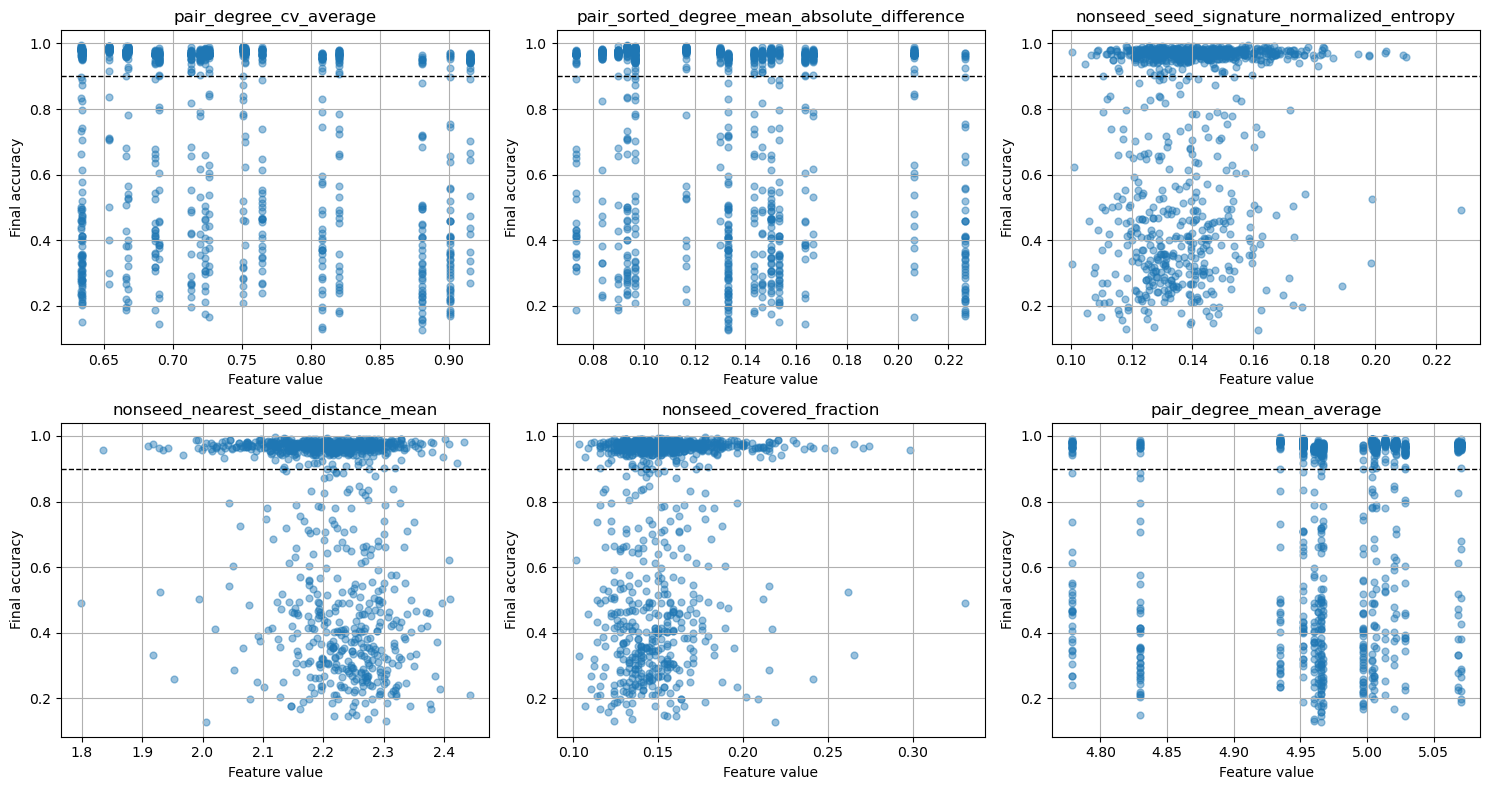

In [8]:
top_features = association_df.nlargest(6, 'absolute_final_spearman')['feature']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.flat, top_features):
    ax.scatter(X[feature], df['final_unseeded_accuracy'], alpha=0.45, s=24)
    ax.axhline(SUCCESS_THRESHOLD, color='black', linestyle='--', linewidth=1)
    ax.set(title=feature, xlabel='Feature value', ylabel='Final accuracy')

fig.tight_layout()
plt.show()

## Models and grouped cross-validation

The random forests provide a simple nonlinear baseline. The comparison models predict the training-fold mean for regression and the training-fold class prior for classification. Every fold holds out complete graph pairs.

In [9]:
def make_regressor():
    return Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=8,
                    max_features=0.7,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_classifier():
    return Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                RandomForestClassifier(
                    n_estimators=300,
                    min_samples_leaf=8,
                    max_features=0.7,
                    class_weight='balanced',
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def make_regression_baseline():
    return Pipeline(
        [('imputer', SimpleImputer(strategy='median')), ('model', DummyRegressor())]
    )


def make_classification_baseline():
    return Pipeline(
        [
            ('imputer', SimpleImputer(strategy='median')),
            ('model', DummyClassifier(strategy='prior')),
        ]
    )


def spearman_score(y_true, y_pred):
    return pd.Series(y_true).corr(pd.Series(y_pred), method='spearman')


n_splits = min(5, groups.nunique())
group_cv = GroupKFold(n_splits=n_splits)
print(f'Using {n_splits}-fold grouped cross-validation.')

Using 5-fold grouped cross-validation.


### Regression: H0 and final accuracy

MAE and RMSE measure prediction error, (R^2) measures explained variation, and Spearman correlation measures whether the model ranks seed sets in a useful order.

In [10]:
regression_scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R_squared': 'r2',
    'Spearman': make_scorer(spearman_score),
}
regression_rows = []

for target in CONTINUOUS_TARGETS:
    y = df[target]
    for name, estimator in [
        ('Mean baseline', make_regression_baseline()),
        ('Random forest', make_regressor()),
    ]:
        scores = cross_validate(
            estimator,
            X,
            y,
            groups=groups,
            cv=group_cv,
            scoring=regression_scoring,
            n_jobs=1,
        )
        regression_rows.append(
            {
                'target': target,
                'model': name,
                'MAE': -scores['test_MAE'].mean(),
                'RMSE': -scores['test_RMSE'].mean(),
                'R_squared': scores['test_R_squared'].mean(),
                'Spearman': scores['test_Spearman'].mean(),
            }
        )

regression_cv_results = pd.DataFrame(regression_rows)
regression_cv_results.round(4)

/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; th

,target,model,MAE,RMSE,R_squared,Spearman
0,h0_accuracy,Mean baseline,0.0074,0.0094,-0.0158,NaN
1,h0_accuracy,Random forest,0.0070,0.0088,0.1102,NaN
2,final_unseeded_accuracy,Mean baseline,0.2621,0.2885,-0.0676,NaN
3,final_unseeded_accuracy,Random forest,0.2449,0.2851,-0.0376,NaN


### Classification: final accuracy of at least 90%

Balanced accuracy weights success and failure equally. ROC AUC and average precision evaluate ranking, while log loss evaluates predicted probabilities.

In [11]:
classification_scoring = {
    'balanced_accuracy': 'balanced_accuracy',
    'ROC_AUC': 'roc_auc',
    'average_precision': 'average_precision',
    'log_loss': 'neg_log_loss',
}
classification_rows = []

for name, estimator in [
    ('Class-prior baseline', make_classification_baseline()),
    ('Random forest', make_classifier()),
]:
    scores = cross_validate(
        estimator,
        X,
        y_class,
        groups=groups,
        cv=group_cv,
        scoring=classification_scoring,
        n_jobs=1,
    )
    classification_rows.append(
        {
            'model': name,
            'balanced_accuracy': scores['test_balanced_accuracy'].mean(),
            'ROC_AUC': scores['test_ROC_AUC'].mean(),
            'average_precision': scores['test_average_precision'].mean(),
            'log_loss': -scores['test_log_loss'].mean(),
        }
    )

classification_cv_results = pd.DataFrame(classification_rows)
classification_cv_results.round(4)

,model,balanced_accuracy,ROC_AUC,average_precision,log_loss
0,Class-prior baseline,0.5000,0.5000,0.6170,0.6758
1,Random forest,0.6138,0.6503,0.7387,0.6671


## One held-out set of graph pairs

This split supplies diagnostic plots and feature importance. The grouped cross-validation tables above are the more stable performance estimates.

In [12]:
splitter = GroupShuffleSplit(
    n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE
)
train_index, test_index = next(splitter.split(X, y_class, groups=groups))

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_class_train, y_class_test = y_class.iloc[train_index], y_class.iloc[test_index]
train_groups = set(groups.iloc[train_index])
test_groups = set(groups.iloc[test_index])

assert train_groups.isdisjoint(test_groups)
if y_class_train.nunique() != 2 or y_class_test.nunique() != 2:
    raise ValueError(
        'This held-out split contains only one class. Change RANDOM_STATE or TEST_FRACTION.'
    )

print(f'Training graph pairs: {len(train_groups)}')
print(f'Test graph pairs: {len(test_groups)}')
print(f'Training success rate: {y_class_train.mean():.1%}')
print(f'Test success rate: {y_class_test.mean():.1%}')

Training graph pairs: 15
Test graph pairs: 5
Training success rate: 63.7%
Test success rate: 55.6%


In [13]:
heldout_regression_rows = []
heldout_regressors = {}

for target in CONTINUOUS_TARGETS:
    y_train = df[target].iloc[train_index]
    y_test = df[target].iloc[test_index]
    for name, estimator in [
        ('Mean baseline', make_regression_baseline()),
        ('Random forest', make_regressor()),
    ]:
        estimator.fit(X_train, y_train)
        prediction = estimator.predict(X_test)
        heldout_regression_rows.append(
            {
                'target': target,
                'model': name,
                'MAE': mean_absolute_error(y_test, prediction),
                'RMSE': np.sqrt(mean_squared_error(y_test, prediction)),
                'R_squared': r2_score(y_test, prediction),
                'Spearman': pd.Series(y_test.to_numpy()).corr(
                    pd.Series(prediction), method='spearman'
                ),
            }
        )
        if name == 'Random forest':
            heldout_regressors[target] = estimator

heldout_regression_results = pd.DataFrame(heldout_regression_rows)
heldout_regression_results.round(4)

/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Users/langsong/miniforge3/envs/ds/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,target,model,MAE,RMSE,R_squared,Spearman
0,h0_accuracy,Mean baseline,0.0069,0.0086,-0.0259,NaN
1,h0_accuracy,Random forest,0.0060,0.0075,0.2247,0.4691
2,final_unseeded_accuracy,Mean baseline,0.2690,0.3013,-0.0266,NaN
3,final_unseeded_accuracy,Random forest,0.2818,0.3089,-0.0787,0.0412


In [14]:
classifier = make_classifier()
classification_baseline = make_classification_baseline()
classifier.fit(X_train, y_class_train)
classification_baseline.fit(X_train, y_class_train)

class_probability = classifier.predict_proba(X_test)[:, 1]
baseline_probability = classification_baseline.predict_proba(X_test)[:, 1]
class_prediction = (class_probability >= 0.5).astype(int)
baseline_prediction = classification_baseline.predict(X_test)


def classification_metrics(name, prediction, probability):
    return {
        'model': name,
        'balanced_accuracy': balanced_accuracy_score(y_class_test, prediction),
        'ROC_AUC': roc_auc_score(y_class_test, probability),
        'average_precision': average_precision_score(y_class_test, probability),
        'log_loss': log_loss(y_class_test, probability, labels=[0, 1]),
    }


heldout_classification_results = pd.DataFrame(
    [
        classification_metrics(
            'Class-prior baseline', baseline_prediction, baseline_probability
        ),
        classification_metrics('Random forest', class_prediction, class_probability),
    ]
)
heldout_classification_results.round(4)

,model,balanced_accuracy,ROC_AUC,average_precision,log_loss
0,Class-prior baseline,0.50,0.5000,0.5560,0.7008
1,Random forest,0.47,0.5057,0.5401,0.7671


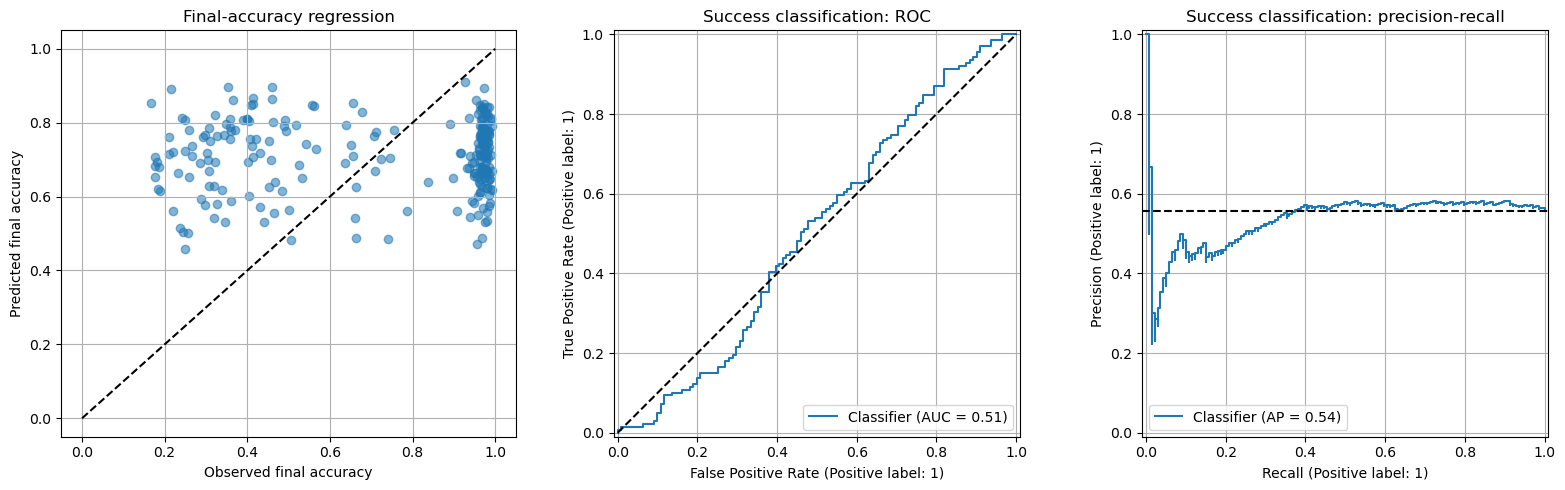

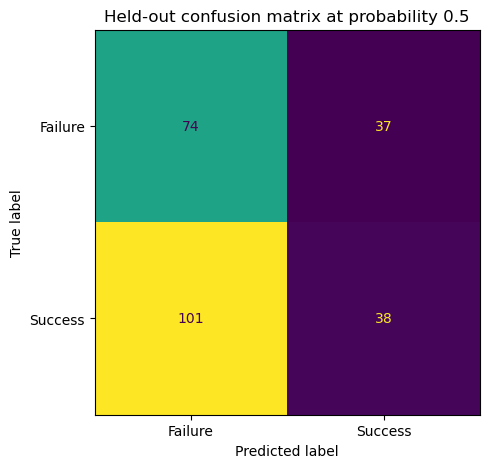

In [15]:
final_test = df['final_unseeded_accuracy'].iloc[test_index]
final_prediction = heldout_regressors['final_unseeded_accuracy'].predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(final_test, final_prediction, alpha=0.55)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black')
axes[0].set(
    title='Final-accuracy regression',
    xlabel='Observed final accuracy',
    ylabel='Predicted final accuracy',
)

RocCurveDisplay.from_predictions(y_class_test, class_probability, ax=axes[1])
axes[1].plot([0, 1], [0, 1], linestyle='--', color='black')
axes[1].set_title('Success classification: ROC')

PrecisionRecallDisplay.from_predictions(y_class_test, class_probability, ax=axes[2])
axes[2].axhline(y_class_test.mean(), linestyle='--', color='black')
axes[2].set_title('Success classification: precision-recall')

fig.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_class_test,
    class_prediction,
    display_labels=['Failure', 'Success'],
    colorbar=False,
)
plt.grid(False)
plt.title('Held-out confusion matrix at probability 0.5')
plt.show()

## Permutation importance

Importance is calculated separately for final-accuracy regression and success classification. Interpret it only when the corresponding random forest clearly beats its baseline. Correlated predictors can divide importance between them.

In [16]:
importance_rows = []
importance_tasks = [
    (
        'Final-accuracy regression',
        heldout_regressors['final_unseeded_accuracy'],
        df['final_unseeded_accuracy'].iloc[test_index],
        'neg_mean_absolute_error',
    ),
    (
        'Success classification',
        classifier,
        y_class_test,
        'roc_auc',
    ),
]

for task, estimator, target, scoring in importance_tasks:
    result = permutation_importance(
        estimator,
        X_test,
        target,
        scoring=scoring,
        n_repeats=15,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    for feature, mean, std in zip(
        feature_columns, result.importances_mean, result.importances_std
    ):
        importance_rows.append(
            {
                'task': task,
                'feature': feature,
                'importance_mean': mean,
                'importance_std': std,
            }
        )

importance_df = pd.DataFrame(importance_rows)
importance_df.sort_values(
    ['task', 'importance_mean'], ascending=[True, False]
).groupby('task').head(10)

,task,feature,importance_mean,importance_std
5,Final-accuracy regression,nonseed_nearest_seed_distance_mean,0.014533,0.003236
15,Final-accuracy regression,pair_sorted_degree_mean_absolute_difference,0.003910,0.001669
4,Final-accuracy regression,nonseed_covered_by_two_fraction,0.002076,0.001072
7,Final-accuracy regression,nonseed_within_two_hops_of_three_seeds_fraction,0.001627,0.000546
10,Final-accuracy regression,seed_nonseed_neighborhood_jaccard_mean,0.001522,0.001035
11,Final-accuracy regression,seed_pair_shortest_path_mean,0.001152,0.000983
8,Final-accuracy regression,nonseed_three_hop_seed_count_mean,0.001046,0.000577
9,Final-accuracy regression,nonseed_seed_signature_normalized_entropy,0.000160,0.000658
3,Final-accuracy regression,nonseed_covered_fraction,0.000008,0.000334
6,Final-accuracy regression,nonseed_nearest_seed_distance_max,0.000006,0.000019


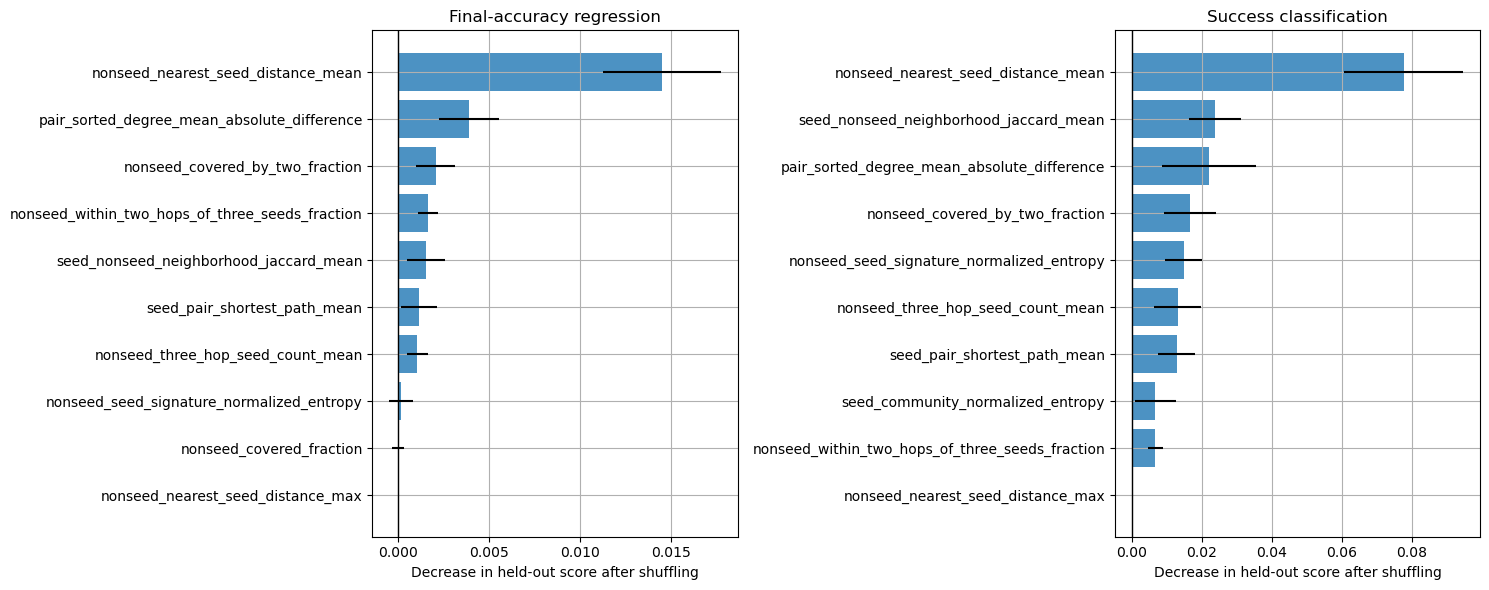

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (task, subset) in zip(axes, importance_df.groupby('task')):
    top = subset.nlargest(10, 'importance_mean').sort_values('importance_mean')
    ax.barh(
        top['feature'],
        top['importance_mean'],
        xerr=top['importance_std'],
        alpha=0.8,
    )
    ax.axvline(0, color='black', linewidth=1)
    ax.set(title=task, xlabel='Decrease in held-out score after shuffling')

fig.tight_layout()
plt.show()

## Reading the results

1. Check the target distributions and success rate before comparing models. Nearly constant H0 or a highly imbalanced success label limits what the models can learn.
2. Use the grouped cross-validation tables as the main estimate of generalization to new graph pairs.
3. For regression, compare MAE and rank correlation with the mean baseline. A negative (R^2) means the model is worse than predicting the training-fold mean.
4. For classification, require improvement over the class-prior baseline in ROC AUC, average precision, and balanced accuracy before interpreting feature importance.
5. Seed features can distinguish candidate sets within a graph pair. Graph-context features only describe differences between graph pairs.
6. Treat importance as exploratory evidence. Agreement across graph models and across regression and classification is stronger evidence than one large importance value.